# Clase 5 — Práctica Individual resuelta
## Datos reales = datos sucios
### Maestría en Fintech · ITBA · 2026

---

Una forma de resolver los 10 ejercicios de `Clase_5_Practica_Individual.ipynb`, con la **lectura de negocio** de cada uno.

> **Hay más de un camino correcto.** Si llegaste al mismo resultado por otra vía, está bien. Y si todavía no la intentaste, hacelo primero: mirar la solución antes es como leer el final de la película.

Ejecutá **`Entorno de ejecución → Ejecutar todo`**: los datos se descargan solos del repo del curso.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

DATOS = 'https://raw.githubusercontent.com/camilojaure/itba-pad/main/datasets/'
sucio      = pd.read_csv(DATOS + 'transacciones_sucias.csv')
clientes   = pd.read_csv(DATOS + 'clientes.csv')
tarjetas   = pd.read_csv(DATOS + 'tarjetas.csv')
referencia = pd.read_csv(DATOS + 'transacciones.csv')   # la tabla conciliada de las clases 3 y 4

print(f'sucio:      {len(sucio):>6,} filas')
print(f'clientes:   {len(clientes):>6,} filas')
print(f'tarjetas:   {len(tarjetas):>6,} filas')
print(f'referencia: {len(referencia):>6,} filas')

sucio:      29,825 filas
clientes:    1,000 filas
tarjetas:    2,110 filas
referencia: 28,956 filas


In [2]:
# La limpieza de la práctica guiada, en una sola celda
limpio = sucio.drop_duplicates().copy()

limpio['categoria'] = limpio['categoria'].str.strip().str.capitalize()
limpio['tipo'] = (limpio['tipo'].str.strip().str.lower()
                  .replace({'credito': 'crédito', 'credit': 'crédito'}))

limpio = limpio[~(limpio['monto_ars'] <= 0)].copy()

veces = limpio['monto_ars'] / limpio.groupby('cliente_id')['monto_ars'].transform('median')
limpio.loc[veces > 20, 'monto_ars'] = np.nan

limpio['categoria'] = limpio['categoria'].fillna('Sin categoría')
limpio['monto_imputado'] = limpio['monto_ars'].isna()
limpio['monto_ars'] = limpio['monto_ars'].fillna(limpio.groupby('categoria')['monto_ars'].transform('mean'))

print(f"limpio: {len(limpio):,} filas · TPV ${limpio['monto_ars'].sum() / 1e6:,.0f} M "
      f"· {limpio['monto_imputado'].sum():,} montos imputados")

limpio: 28,927 filas · TPV $1,774 M · 2,052 montos imputados


---
## Ejercicio 1 · Tu propio checklist

Sobre `sucio`, calculá:

- el **porcentaje de nulos** de cada columna
- cuántas filas tienen **al menos un problema**: algún nulo, o están duplicadas, o tienen monto menor o igual a cero

¿Qué porcentaje del archivo es eso?

*Pista: `sucio.isna().any(axis=1)` te dice, fila por fila, si tiene algún nulo. Combiná las tres condiciones con `|` (o).*

In [3]:
print((sucio.isna().mean() * 100).round(1))

con_nulo      = sucio.isna().any(axis=1)
duplicada     = sucio.duplicated()
no_positivo   = sucio['monto_ars'] <= 0
algun_problema = con_nulo | duplicada | no_positivo

print()
print(f"Filas con algún nulo:            {con_nulo.sum():,}")
print(f"Filas duplicadas:                {duplicada.sum():,}")
print(f"Filas con monto <= 0:            {no_positivo.sum():,}")
print(f"Filas con al menos un problema:  {algun_problema.sum():,} ({algun_problema.mean():.1%})")

transaccion_id    0.0
tarjeta_id        0.0
cliente_id        0.0
fecha             4.0
monto_ars         7.0
categoria         5.0
tipo              0.0
aprobada          0.0
dtype: float64

Filas con algún nulo:            4,525
Filas duplicadas:                869
Filas con monto <= 0:            31
Filas con al menos un problema:  5,281 (17.7%)


**Lectura esperada:** `monto_ars` 7,0% · `categoria` 5,0% · `fecha` 4,0%. Filas con al menos un problema: **5.281, el 17,7%** del archivo
(4.525 con algún nulo, 869 duplicadas, 31 con monto ≤ 0; se superponen).
Borrar todo lo que tiene algún problema es tirar **casi 1 de cada 5 transacciones**, y la mayoría tiene un solo hueco que no afecta
a la pregunta (una compra sin categoría sigue sirviendo para el TPV). Es el analista B de la guiada.

---
## Ejercicio 2 · ¿Los nulos están repartidos al azar?

Uní `sucio` con `clientes` para traer el segmento, y calculá el **porcentaje de montos nulos en cada segmento**.
Hacé lo mismo **por mes** (convertí la fecha primero).

*Pista: el promedio de `monto_ars.isna()` es la proporción de nulos, el mismo truco de la Clase 2 con una columna 0/1.*

In [4]:
t2 = sucio.merge(clientes[['cliente_id', 'segmento']], on='cliente_id', how='left', validate='many_to_one')
t2['monto_nulo'] = t2['monto_ars'].isna()
print(f"{len(sucio):,} → {len(t2):,} filas")

print((t2.groupby('segmento')['monto_nulo'].mean() * 100).round(1))

29,825 → 29,825 filas
segmento
Joven      7.0
Premium    6.8
PyME       7.3
Retail     6.9
Name: monto_nulo, dtype: float64


In [5]:
t2['mes'] = pd.to_datetime(t2['fecha']).dt.month
(t2.groupby('mes')['monto_nulo'].mean() * 100).round(1)

mes
1.0     6.3
2.0     6.6
3.0     6.5
4.0     7.5
5.0     7.1
6.0     7.2
7.0     6.6
8.0     7.2
9.0     7.5
10.0    6.8
11.0    6.9
12.0    7.7
Name: monto_nulo, dtype: float64

**Lectura esperada:** Los nulos de monto están **parejos**: entre 6,8% y 7,3% por segmento, y entre 6,3% y 7,7% por mes.
No hay un grupo donde falten más. Eso es lo que hace que eliminarlos o imputarlos con un promedio **no sesgue** los promedios
(sí baja el total, ejercicio 6).
Si todos los nulos fueran de Premium, eliminarlos sacaría del análisis justo al segmento que pone la mitad del gasto (Clase 4),
y el ticket promedio caería. **Antes de decidir qué hacer con un nulo, hay que mirar dónde está.**

---
## Ejercicio 3 · Débito y crédito, antes y después

¿Qué porcentaje del **monto** se paga con débito y qué porcentaje con crédito?
Calculalo dos veces: sobre `sucio` **sin tocar** y sobre `limpio`.

*Pista: `groupby('tipo')['monto_ars'].sum()` y dividí por el total.*

In [6]:
antes = sucio.groupby('tipo')['monto_ars'].sum()
antes = (antes / antes.sum() * 100).round(1).sort_values(ascending=False)
print(f'ANTES: {len(antes)} filas')
print(antes)

despues = limpio.groupby('tipo')['monto_ars'].sum()
print()
print('DESPUÉS')
print((despues / despues.sum() * 100).round(1))

ANTES: 11 filas
tipo
débito       40.2
crédito      39.6
CREDITO       3.0
DÉBITO        2.8
Débito        2.6
débito        2.6
 débito       2.5
credit        1.9
 crédito      1.8
Crédito       1.6
credito       1.5
Name: monto_ars, dtype: float64

DESPUÉS
tipo
crédito    46.9
débito     53.1
Name: monto_ars, dtype: float64


**Lectura esperada:** Antes: **11 filas**, y los dos "tipos" principales parecen casi empatados (débito 40,2%, crédito 39,6%),
con nueve variantes chicas abajo. Después: **débito 53,1% · crédito 46,9%**.
Un gerente que mire la tabla sucia puede concluir que hay "otros medios de pago" o que el crédito está a la par del débito.
Es el mismo problema de las 50 categorías de la guiada, ahora en una columna con solo dos valores reales.

---
## Ejercicio 4 · Los montos negativos

Mirá de cerca las transacciones con **monto negativo** en `sucio` (sin duplicados):
¿cuántas son, en qué categorías, de qué tipo de tarjeta, están aprobadas? ¿Cuánto suman?

*Pista: filtrá y usá `value_counts()` sobre cada columna que te interese.*

In [7]:
sin_dup = sucio.drop_duplicates()
neg = sin_dup[sin_dup['monto_ars'] < 0]

print(f"{len(neg)} transacciones negativas · suman ${neg['monto_ars'].sum():,.0f}")
print()
print(neg['categoria'].str.strip().str.capitalize().value_counts())
print()
print(neg['tipo'].str.strip().str.lower().value_counts())
print()
print(neg['aprobada'].value_counts())

14 transacciones negativas · suman $-1,303,626

categoria
Supermercado    5
Servicios       2
Indumentaria    2
Restaurant      2
Viajes          2
Combustible     1
Name: count, dtype: int64

tipo
débito     10
crédito     4
Name: count, dtype: int64

aprobada
1    14
Name: count, dtype: int64


**Lectura esperada:** **14 transacciones** negativas (16 antes de sacar duplicados), por **−$1,3 M**. Son de categorías de consumo comunes
(Supermercado 5, y el resto repartido), 10 de débito y 4 de crédito, y **todas aprobadas**.
No se puede saber si son devoluciones: faltaría un **campo de tipo de operación** (compra / devolución / contracargo) o la
transacción original a la que refieren. Se le pregunta a **operaciones** o al procesador.
Con 14 filas y $1,3 M la decisión casi no mueve el TPV; con 3.000 sería el primer tema de la reunión.

---
## Ejercicio 5 · El límite de la tarjeta como validación

Una compra con tarjeta de **crédito** no debería superar el **límite** de esa tarjeta. Usalo para validar los montos:

1. Quedate con las transacciones de `sucio` sin duplicados y con `tipo` normalizado a `crédito`
2. Uní con `tarjetas` para traer el `limite_credito` (la clave es `tarjeta_id`)
3. ¿Cuántas superan el límite? Para cada una, calculá **cuántas veces el límite** es el monto

*Pista: es un join de la Clase 4. Antes de unir, predecí cuántas filas tienen que salir, y después contalas.*

In [8]:
t5 = sucio.drop_duplicates().copy()
t5['tipo'] = t5['tipo'].str.strip().str.lower().replace({'credito': 'crédito', 'credit': 'crédito'})
credito = t5[t5['tipo'] == 'crédito']

# Cada transacción tiene una sola tarjeta: tienen que salir las mismas filas
t5 = credito.merge(tarjetas[['tarjeta_id', 'tipo_tarjeta', 'limite_credito']], on='tarjeta_id',
                   how='left', validate='many_to_one')
print(f"{len(credito):,} → {len(t5):,} filas")

pasadas = t5[t5['monto_ars'] > t5['limite_credito']].copy()
pasadas['veces_el_limite'] = (pasadas['monto_ars'] / pasadas['limite_credito']).round(1)
print(f"{len(pasadas)} compras superan el límite de la tarjeta")
pasadas.sort_values('veces_el_limite', ascending=False)[
    ['transaccion_id', 'cliente_id', 'categoria', 'monto_ars', 'limite_credito', 'veces_el_limite']]

10,630 → 10,630 filas
12 compras superan el límite de la tarjeta


,transaccion_id,cliente_id,categoria,monto_ars,limite_credito,veces_el_limite
1024,TX009556,C0443,Viajes,7010046.81,120000,58.4
8645,TX014323,C0622,Indumentaria,57548141.56,2840000,20.3
8740,TX023609,C0107,Supermercado,42104614.69,2220000,19.0
8551,TX016221,C0803,Salud,25696495.85,3630000,7.1
1399,TX004809,C0650,indumentaria,55301794.82,9210000,6.0
705,TX000946,C0694,Entretenimiento,1871960.75,400000,4.7
1507,TX022426,C0822,Viajes,175131.01,70000,2.5
4120,TX009976,C0822,Viajes,157052.50,70000,2.2
92,TX027880,C0943,Viajes,201536.18,110000,1.8
3467,TX011447,C0194,Restaurant,2820008.20,1560000,1.8


**Lectura esperada:** 10.630 → 10.630 filas (bien: cada transacción tiene una tarjeta). **12 compras superan el límite.**

- Las que lo superan por **6 veces o más** (un Joven con una compra de $7 M sobre un límite de $120.000; ropa de $57 M sobre $2,8 M) son errores seguros
- Las que lo pasan **por poco** (1,1 a 2,5 veces) pueden ser reales: sobregiros autorizados, límites que cambiaron durante el año.
  En la tabla de referencia hay **5 compras reales** que superan el límite

La regla sirve como segunda validación, pero tiene dos límites: **no distingue bien los casos intermedios**
(hay errores a 1,8 y 4,7 veces el límite) y **no sirve para débito**, que no tiene límite. De las 26 sospechosas de la guiada,
la mayoría eran de débito. Por eso la regla de la guiada compara contra **el propio cliente**, que funciona para los dos tipos.

---
## Ejercicio 6 · Imputar tiene un precio

Partiendo de `sucio` sin duplicados, sin montos no positivos y con la categoría normalizada, compará **tres formas** de tratar los montos nulos:

| Estrategia | Qué hace |
|---|---|
| Eliminar | Se descartan las filas sin monto |
| Mediana de la categoría | Se completan con la mediana del monto de su categoría |
| Promedio de la categoría | Se completan con el promedio del monto de su categoría |

Para cada una, calculá el **TPV** y el **desvío estándar** del monto. Comparalos con la `referencia`.
(Para que la comparación sea justa, antes sacá los **montos gigantes** como en la guiada.)

*Pista: `groupby('categoria')['monto_ars'].transform('median')` te da, para cada fila, la mediana de su categoría.*

In [9]:
base = sucio.drop_duplicates().copy()
base['categoria'] = base['categoria'].str.strip().str.capitalize().fillna('Sin categoría')
base = base[~(base['monto_ars'] <= 0)].copy()
veces = base['monto_ars'] / base.groupby('cliente_id')['monto_ars'].transform('median')
base.loc[veces > 20, 'monto_ars'] = np.nan

por_cat = base.groupby('categoria')['monto_ars']
estrategias = {
    'Eliminar':                 base['monto_ars'].dropna(),
    'Mediana de la categoría':  base['monto_ars'].fillna(por_cat.transform('median')),
    'Promedio de la categoría': base['monto_ars'].fillna(por_cat.transform('mean')),
    'Referencia':               referencia['monto_ars'],
}
t6 = pd.DataFrame({
    'filas':     {k: len(v) for k, v in estrategias.items()},
    'TPV ($M)':  {k: round(v.sum() / 1e6, 1) for k, v in estrategias.items()},
    'desvío ($)': {k: round(v.std()) for k, v in estrategias.items()},
})
t6['TPV vs. ref.'] = (t6['TPV ($M)'] / t6.loc['Referencia', 'TPV ($M)'] - 1).map('{:+.1%}'.format)
t6

,filas,TPV ($M),desvío ($),TPV vs. ref.
Eliminar,26875,1647.6,80093,-7.1%
Mediana de la categoría,28927,1738.7,77890,-2.0%
Promedio de la categoría,28927,1774.0,78123,+0.0%
Referencia,28956,1773.9,80048,+0.0%


**Lectura esperada:**

| Estrategia | TPV | vs. referencia | Desvío |
|---|---|---|---|
| Eliminar | $1.648 M | **−7,1%** | $80.093 |
| Mediana de la categoría | $1.739 M | −2,0% | $77.890 |
| Promedio de la categoría | $1.774 M | ≈ 0% | $78.123 |
| Referencia | $1.774 M | — | $80.048 |

- **Eliminar** subestima el total en lo mismo que falta: 7%
- **La mediana** se queda corta porque los montos son asimétricos (la mediana está por debajo del promedio; es la Clase 2)
- **El promedio** clava el total, pero **baja el desvío** (78.123 contra 80.048): 2.052 filas con el mismo valor achican la dispersión.
 

Para un **ticket promedio** o cualquier análisis de dispersión, conviene **eliminar** (o trabajar solo con los observados):
los nulos están al azar (ejercicio 2), así que no sesgan el promedio y no inventan filas.

---
## Ejercicio 7 · El año que no fue

Graficá el **TPV mensual** de 2024 en el mismo gráfico, dos líneas:

- `sucio` tal como viene (sin limpiar nada)
- `limpio`

Las filas sin fecha no entran en ninguna de las dos: no se pueden ubicar en un mes.

*Pista: `pd.to_datetime` y `.dt.month`, como en la Clase 3. Armá las dos series y juntalas en un DataFrame para graficar.*

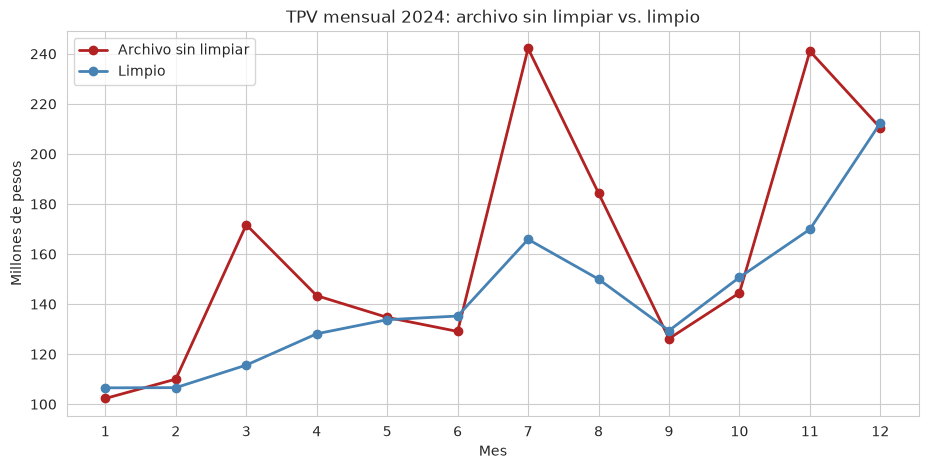

       Archivo sin limpiar  Limpio
fecha                             
1                    102.0   107.0
2                    110.0   107.0
3                    172.0   116.0
4                    143.0   128.0
5                    135.0   134.0
6                    129.0   135.0
7                    242.0   166.0
8                    184.0   150.0
9                    126.0   129.0
10                   144.0   151.0
11                   241.0   170.0
12                   210.0   212.0

Mejor mes sin limpiar: 7 · limpio: 12
TPV sin mes (fecha nula): $70 M en 1,157 filas


In [10]:
def tpv_mensual(t):
    meses = pd.to_datetime(t['fecha']).dt.month       # las fechas nulas quedan NaT y el groupby las deja afuera
    return t.groupby(meses)['monto_ars'].sum() / 1e6

t7 = pd.DataFrame({'Archivo sin limpiar': tpv_mensual(sucio), 'Limpio': tpv_mensual(limpio)})
t7.index = t7.index.astype(int)

t7.plot(marker='o', linewidth=2, color=['firebrick', 'steelblue'])
plt.title('TPV mensual 2024: archivo sin limpiar vs. limpio')
plt.ylabel('Millones de pesos')
plt.xlabel('Mes')
plt.xticks(range(1, 13))
plt.show()

print(t7.round(0))
print()
print(f"Mejor mes sin limpiar: {t7['Archivo sin limpiar'].idxmax()} · limpio: {t7['Limpio'].idxmax()}")
sin_fecha = limpio[limpio['fecha'].isna()]
print(f"TPV sin mes (fecha nula): ${sin_fecha['monto_ars'].sum() / 1e6:,.0f} M en {len(sin_fecha):,} filas")

**Lectura esperada:** Con el archivo sin limpiar, **julio parece el mejor mes del año** ($242 M) y noviembre queda segundo ($241 M);
marzo salta un 56% sobre febrero. Con el limpio, el patrón de la Clase 3 vuelve: crecimiento sostenido y **pico en diciembre** ($212 M).
Con el archivo sucio, el directorio habría escuchado *"julio fue récord, algo pasó en marzo"*, y alguien habría salido a buscar
una campaña exitosa que no existió: eran compras con ceros de más.
**$70 M** (1.157 transacciones) quedan sin mes: entran en el TPV anual, no en la serie.

---
## Ejercicio 8 · El ticket promedio por categoría

Armá una tabla con el **ticket promedio por categoría** en tres columnas: `sucio` (con la categoría normalizada, pero sin ninguna otra limpieza),
`limpio` (solo los montos **no imputados**) y `referencia`. Agregá el **error del sucio** en %.

*Pista: tres `groupby` y un `pd.DataFrame({...})` para juntarlos, como en el Paso 7 de la guiada.*

In [11]:
cat_sucia = sucio['categoria'].str.strip().str.capitalize()
observados = limpio[~limpio['monto_imputado']]

t8 = pd.DataFrame({
    'sucio':      sucio.groupby(cat_sucia)['monto_ars'].mean(),
    'limpio':     observados.groupby('categoria')['monto_ars'].mean(),
    'referencia': referencia.groupby('categoria')['monto_ars'].mean(),
}).drop(index='Sin categoría', errors='ignore')
t8['error del sucio (%)'] = (t8['sucio'] / t8['referencia'] - 1) * 100
t8.round(0).sort_values('error del sucio (%)', ascending=False)

,sucio,limpio,referencia,error del sucio (%)
categoria,,,,
Indumentaria,136137.0,81197.0,81227.0,68.0
Combustible,44865.0,35584.0,35480.0,26.0
Supermercado,61283.0,49721.0,49709.0,23.0
Servicios,27489.0,22907.0,22953.0,20.0
Salud,87659.0,71919.0,73713.0,19.0
Transferencia,162534.0,138031.0,137565.0,18.0
Restaurant,54352.0,48498.0,48211.0,13.0
Entretenimiento,28061.0,27195.0,27105.0,4.0
Viajes,228776.0,223061.0,224008.0,2.0


In [12]:
# ¿Quién explica Indumentaria?
sucio.assign(cat=cat_sucia).query("cat == 'Indumentaria'").nlargest(3, 'monto_ars')[['transaccion_id', 'cliente_id', 'monto_ars']]

,transaccion_id,cliente_id,monto_ars
23966,TX014323,C0622,57548141.56
3746,TX004809,C0650,55301794.82
26469,TX003366,C0884,7380616.81


**Lectura esperada:** La más distorsionada es **Indumentaria: +68%** ($136.137 contra $81.227). La explican **dos filas**:
dos compras de ropa de $57 M y $55 M, sobre 2.273. Le siguen Combustible (+26%) y Supermercado (+23%).
Viajes y E-commerce casi no cambian: sus errores se diluyen en tickets grandes o no los tuvieron.
En el limpio se usan solo los montos **observados** porque los imputados se completaron **con el promedio de la categoría**:
incluirlos en el promedio sería medir lo que nosotros mismos pusimos.

---
## Ejercicio 9 · Las tablas, ¿cierran entre sí?

Un chequeo que no se hace mirando una sola tabla. Sobre `limpio`, verificá:

1. ¿Todos los `cliente_id` de las transacciones existen en `clientes`?
2. ¿Todas las `tarjeta_id` existen en `tarjetas`?
3. ¿Cada tarjeta pertenece **al mismo cliente** en las dos tablas?
4. ¿El `tipo` de la transacción coincide con el `tipo_tarjeta` de la tarjeta (débito con débito, crédito con crédito)?

*Pista: para 1 y 2, `isin`. Para 3 y 4, un `merge` con `tarjetas` por `tarjeta_id` y comparar columnas.*

In [13]:
print(f"cliente_id que no están en clientes: {(~limpio['cliente_id'].isin(clientes['cliente_id'])).sum()}")
print(f"tarjeta_id que no están en tarjetas: {(~limpio['tarjeta_id'].isin(tarjetas['tarjeta_id'])).sum()}")

t9 = limpio.merge(tarjetas[['tarjeta_id', 'cliente_id', 'tipo_tarjeta']], on='tarjeta_id',
                  how='left', suffixes=('', '_tarjeta'), validate='many_to_one')
print(f"{len(limpio):,} → {len(t9):,} filas")
print(f"Tarjeta de otro cliente: {(t9['cliente_id'] != t9['cliente_id_tarjeta']).sum()}")

es_credito = t9['tipo_tarjeta'].str.contains('Crédito')
print(f"Tipo que no coincide:    {((t9['tipo'] == 'crédito') != es_credito).sum()}")

cliente_id que no están en clientes: 0
tarjeta_id que no están en tarjetas: 0
28,927 → 28,927 filas
Tarjeta de otro cliente: 0
Tipo que no coincide:    0


**Lectura esperada:** **Todo cierra.** 0 clientes huérfanos, 0 tarjetas huérfanas, 0 tarjetas de otro cliente, 0 tipos que no coinciden.
Que no aparezca nada **también es un resultado**: ahora se puede decir "el archivo es consistente con el maestro de clientes y de tarjetas",
y eso vale para quien firma el número.
En la vida real este chequeo casi siempre encuentra algo: clientes dados de baja en el CRM que siguen transaccionando,
tarjetas reasignadas, códigos que cambian con una migración.

---
## Ejercicio 10 · Desafío: `reporte_calidad(df)`

In [14]:
def reporte_calidad(df):
    print(f"{len(df):,} filas · {df.shape[1]} columnas · {df.duplicated().sum():,} filas duplicadas")
    filas = []
    for col in df.columns:
        fila = {
            'columna': col,
            'tipo': str(df[col].dtype),
            'nulos': df[col].isna().sum(),
            '% nulos': round(df[col].isna().mean() * 100, 1),
            'distintos': df[col].nunique(),
        }
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
            p99 = df[col].quantile(0.99)
            fila['ceros o negativos'] = (df[col] <= 0).sum()
            fila['max / p99'] = round(df[col].max() / p99, 1) if p99 > 0 else None
        filas.append(fila)
    return pd.DataFrame(filas).set_index('columna')

reporte_calidad(sucio)

29,825 filas · 8 columnas · 869 filas duplicadas


,tipo,nulos,% nulos,distintos,ceros o negativos,max / p99
columna,,,,,,
transaccion_id,object,0,0.0,28956,NaN,NaN
tarjeta_id,object,0,0.0,2007,NaN,NaN
cliente_id,object,0,0.0,905,NaN,NaN
fecha,object,1200,4.0,366,NaN,NaN
monto_ars,float64,2084,7.0,26872,31.0,136.1
categoria,object,1494,5.0,50,NaN,NaN
tipo,object,0,0.0,11,NaN,NaN
aprobada,int64,0,0.0,2,1483.0,1.0


In [15]:
reporte_calidad(limpio)

28,927 filas · 9 columnas · 0 filas duplicadas


,tipo,nulos,% nulos,distintos,ceros o negativos,max / p99
columna,,,,,,
transaccion_id,object,0,0.0,28927,NaN,NaN
tarjeta_id,object,0,0.0,2007,NaN,NaN
cliente_id,object,0,0.0,905,NaN,NaN
fecha,object,1157,4.0,366,NaN,NaN
monto_ars,float64,0,0.0,26842,0.0,5.5
categoria,object,0,0.0,11,NaN,NaN
tipo,object,0,0.0,2,NaN,NaN
aprobada,int64,0,0.0,2,1432.0,1.0
monto_imputado,bool,0,0.0,2,NaN,NaN


In [16]:
reporte_calidad(clientes)

1,000 filas · 10 columnas · 0 filas duplicadas


,tipo,nulos,% nulos,distintos,ceros o negativos,max / p99
columna,,,,,,
cliente_id,object,0,0.0,1000,NaN,NaN
nombre,object,0,0.0,799,NaN,NaN
edad,int64,0,0.0,50,0.0,1.1
provincia,object,0,0.0,7,NaN,NaN
segmento,object,0,0.0,4,NaN,NaN
antiguedad_años,float64,0,0.0,147,0.0,1.0
balance_ars,float64,0,0.0,927,0.0,2.0
cant_productos,int64,0,0.0,6,0.0,1.0
cliente_activo,bool,0,0.0,2,NaN,NaN


**Lectura esperada:** El reporte sobre `sucio` muestra en una tabla todo el diagnóstico de la guiada: 869 duplicadas, nulos en tres columnas,
**50 categorías y 11 tipos** (la columna `distintos` delata el texto inconsistente), 31 montos ≤ 0 y **max/p99 = 136**.
Sobre `limpio`: 0 duplicados, 11 categorías, 2 tipos, max/p99 = 5,5.
Sobre `clientes` aparece algo interesante: **801 "ceros o negativos" en `churn`**. No es un problema: es una columna 0/1.
**El reporte da señales, no veredictos**: alguien que conoce el negocio tiene que leerlo.